# Day 04 — Sentence Embeddings

## Objectives

- Generate embeddings for 10 sentences using `sentence-transformers`
- Understand the shape of embedding vectors
- Compute a cosine-similarity matrix
- Build a tiny semantic search system
- Find the closest sentence to a query
- Reduce embeddings to 2D using PCA
- Visualize and interpret sentence clusters

## Key idea

TF-IDF represents text using word importance.

Sentence embeddings represent text using semantic meaning.

In this notebook, we will convert complete sentences into dense numerical vectors and use those vectors to measure semantic similarity.

## 1. Import the required libraries

We need:

- `SentenceTransformer` to create sentence embeddings
- `cosine_similarity` to compare vectors
- `numpy` for numerical operations
- `pandas` for displaying similarity results
- `matplotlib` for visualization
- `PCA` to reduce high-dimensional embeddings to 2 dimensions

In [1]:
from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Create 10 sentences

We will intentionally create sentences from different topics.

The topics include:

- Programming
- Machine learning
- Food
- Travel

Having different topics makes it easier to observe semantic clusters later.

In [2]:
sentences = [
    "Python is a popular programming language.",
    "I enjoy writing Python code.",
    "Software developers use Python to build applications.",
    "Machine learning models learn patterns from data.",
    "Artificial intelligence can learn from large datasets.",
    "Training a machine learning model requires data.",
    "I love eating pizza and pasta.",
    "Cooking healthy meals is one of my hobbies.",
    "I enjoy traveling to new places.",
    "Traveling allows me to explore different cultures."
]

print(f"Number of sentences: {len(sentences)}")

for i, sentence in enumerate(sentences, start=1):
    print(f"{i}. {sentence}")

Number of sentences: 10
1. Python is a popular programming language.
2. I enjoy writing Python code.
3. Software developers use Python to build applications.
4. Machine learning models learn patterns from data.
5. Artificial intelligence can learn from large datasets.
6. Training a machine learning model requires data.
7. I love eating pizza and pasta.
8. Cooking healthy meals is one of my hobbies.
9. I enjoy traveling to new places.
10. Traveling allows me to explore different cultures.


## 3. Load a sentence-transformer model

A sentence-transformer takes a sentence as input and produces a dense numerical vector called an embedding.

We will use:

`all-MiniLM-L6-v2`

The model produces a fixed-size embedding for each sentence.

The important idea is:

Text → Embedding vector

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

D:\arun\ai-learning\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\god\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.


## 4. Generate sentence embeddings

Now we convert all 10 sentences into dense vectors.

Each sentence will become a numerical vector.

For example:

Sentence:

"I enjoy writing Python code."

might become conceptually:

[0.021, -0.134, 0.562, ...]

The actual embedding contains many numerical dimensions.

In [4]:
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Embedding shape: (10, 384)


## 5. Inspect one embedding

Let's look at the embedding generated for the first sentence.

The vector contains numerical values representing information learned by the model about the sentence.

In [5]:
print("Sentence:")
print(sentences[0])

print("\nEmbedding:")
print(embeddings[0])

print("\nEmbedding dimensions:")
print(len(embeddings[0]))

Sentence:
Python is a popular programming language.

Embedding:
[-3.08317114e-02 -1.33598680e-02 -9.17528197e-03  1.17876800e-02
 -3.82964015e-02 -1.15767352e-01  9.77412146e-03  9.26624313e-02
 -4.56491001e-02  2.23222971e-02 -2.55731232e-02  6.79148510e-02
  6.82546496e-02  4.59249541e-02  7.08666071e-02 -3.43021750e-02
 -8.17520320e-02 -4.43923846e-02  2.06385516e-02 -1.45590797e-01
 -8.03904757e-02  3.70667130e-02 -8.42211396e-03  4.30315733e-03
  3.04383691e-02 -1.69310458e-02 -4.40547429e-03 -3.19071524e-02
  1.24903042e-02 -5.31150121e-03 -6.92989081e-02  1.08766839e-01
  5.14886864e-02 -1.17149977e-02 -4.05970088e-04  4.72921506e-02
 -1.16852904e-02 -8.49936306e-02 -5.19409180e-02  2.10666507e-02
 -6.88975304e-02  5.69151342e-02 -1.66273657e-02 -4.40136492e-02
 -5.24170026e-02  4.13457379e-02 -5.70358485e-02  2.43253633e-03
  4.59906238e-04  2.85826856e-03 -9.13769901e-02  3.05287261e-03
 -3.93199809e-02 -6.62349463e-02 -6.27441611e-03 -5.07331938e-02
  4.67268750e-02 -1.720732

## 6. Compute cosine similarity

Now we compare every sentence with every other sentence.

Cosine similarity measures how similar the directions of two vectors are.

A higher value means the embeddings are more similar.

Because we have 10 sentences, the result will be a:

10 × 10

similarity matrix.

In [6]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity matrix shape:")
print(similarity_matrix.shape)

Similarity matrix shape:
(10, 10)


## 7. Display the cosine-similarity matrix

Let's convert the similarity matrix into a pandas DataFrame so it is easier to read.

The rows represent the first sentence.

The columns represent the sentence being compared against it.

In [7]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i}" for i in range(1, 11)],
    columns=[f"S{i}" for i in range(1, 11)]
)

similarity_df.round(3)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
S1,1.000,0.756,0.730,0.147,0.234,0.099,0.141,0.062,0.143,0.187
S2,0.756,1.000,0.666,0.178,0.208,0.106,0.269,0.197,0.350,0.219
S3,0.730,0.666,1.000,0.132,0.172,0.112,0.072,0.051,0.106,0.099
S4,0.147,0.178,0.132,1.000,0.614,0.676,0.061,0.043,0.090,0.060
S5,0.234,0.208,0.172,0.614,1.000,0.558,0.086,0.066,0.121,0.153
S6,0.099,0.106,0.112,0.676,0.558,1.000,-0.023,0.029,-0.012,0.028
S7,0.141,0.269,0.072,0.061,0.086,-0.023,1.000,0.536,0.404,0.214
S8,0.062,0.197,0.051,0.043,0.066,0.029,0.536,1.000,0.237,0.213
S9,0.143,0.350,0.106,0.090,0.121,-0.012,0.404,0.237,1.000,0.669
S10,0.187,0.219,0.099,0.060,0.153,0.028,0.214,0.213,0.669,1.000


## 8. Find the most similar sentence for each sentence

The diagonal contains self-similarity values of 1.0.

We do not want a sentence to find itself.

Therefore, we temporarily ignore the diagonal and find the highest remaining similarity score.

In [8]:
for i in range(len(sentences)):
    scores = similarity_matrix[i].copy()

    # Ignore similarity with itself
    scores[i] = -1

    best_match = np.argmax(scores)

    print(f"Sentence {i + 1}:")
    print(f"  {sentences[i]}")
    print(f"Closest sentence:")
    print(f"  {sentences[best_match]}")
    print(f"Similarity: {scores[best_match]:.3f}")
    print()

Sentence 1:
  Python is a popular programming language.
Closest sentence:
  I enjoy writing Python code.
Similarity: 0.756

Sentence 2:
  I enjoy writing Python code.
Closest sentence:
  Python is a popular programming language.
Similarity: 0.756

Sentence 3:
  Software developers use Python to build applications.
Closest sentence:
  Python is a popular programming language.
Similarity: 0.730

Sentence 4:
  Machine learning models learn patterns from data.
Closest sentence:
  Training a machine learning model requires data.
Similarity: 0.676

Sentence 5:
  Artificial intelligence can learn from large datasets.
Closest sentence:
  Machine learning models learn patterns from data.
Similarity: 0.614

Sentence 6:
  Training a machine learning model requires data.
Closest sentence:
  Machine learning models learn patterns from data.
Similarity: 0.676

Sentence 7:
  I love eating pizza and pasta.
Closest sentence:
  Cooking healthy meals is one of my hobbies.
Similarity: 0.536

Sentence 8:
 

## 9. Build a tiny semantic search system

Now we will create a small search function.

The user gives a query.

The query is converted into an embedding.

We compare the query embedding with all sentence embeddings.

The sentence with the highest cosine similarity is returned.

In [9]:
def find_closest_sentence(query):
    query_embedding = model.encode([query])

    scores = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    best_index = np.argmax(scores)

    return sentences[best_index], scores[best_index]

## 10. Test semantic search

Let's test the search system with queries that do not exactly match the original sentences.

This demonstrates why embeddings are useful.

The search should use semantic meaning rather than exact word matching.

In [10]:
queries = [
    "I like programming with Python",
    "How do computers learn from information?",
    "I want to eat Italian food",
    "I want to visit foreign countries"
]

for query in queries:
    sentence, score = find_closest_sentence(query)

    print(f"Query: {query}")
    print(f"Closest sentence: {sentence}")
    print(f"Similarity: {score:.3f}")
    print("-" * 70)

Query: I like programming with Python
Closest sentence: I enjoy writing Python code.
Similarity: 0.853
----------------------------------------------------------------------
Query: How do computers learn from information?
Closest sentence: Machine learning models learn patterns from data.
Similarity: 0.550
----------------------------------------------------------------------
Query: I want to eat Italian food
Closest sentence: I love eating pizza and pasta.
Similarity: 0.560
----------------------------------------------------------------------
Query: I want to visit foreign countries
Closest sentence: Traveling allows me to explore different cultures.
Similarity: 0.453
----------------------------------------------------------------------


## 11. Reduce embeddings to 2 dimensions using PCA

Our embeddings have many dimensions.

For example:

384 dimensions

We cannot easily visualize 384 dimensions on a normal 2D graph.

PCA reduces the embeddings from:

384 dimensions → 2 dimensions

while trying to preserve as much important variation as possible.

This allows us to plot the sentences.

In [11]:
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print("Original shape:", embeddings.shape)
print("Reduced shape:", embeddings_2d.shape)

Original shape: (10, 384)
Reduced shape: (10, 2)


## 12. Plot the sentence embeddings

Each point represents one sentence.

Sentences that have similar embeddings may appear closer together.

We will label every point so we can understand which sentences are near each other.

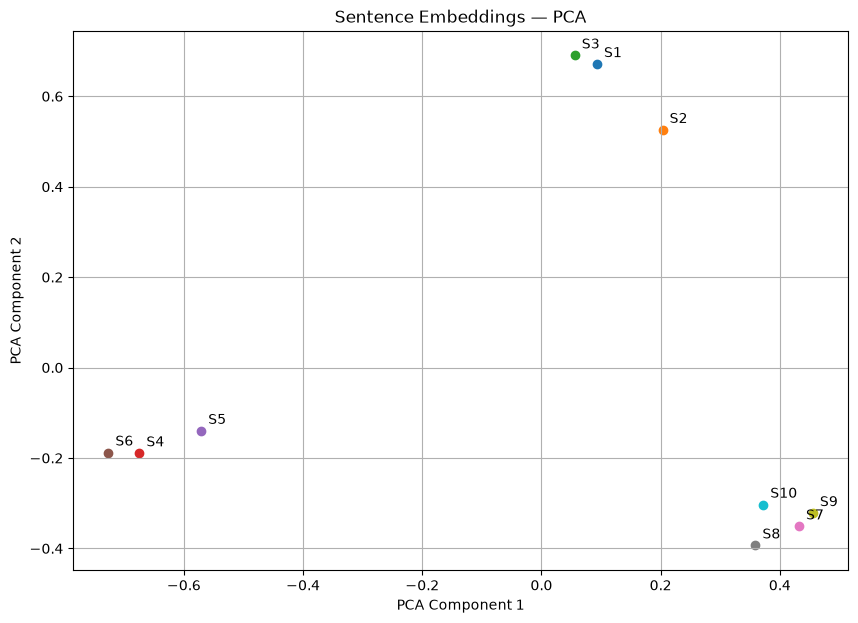

In [12]:
plt.figure(figsize=(10, 7))

for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y)
    plt.annotate(
        f"S{i + 1}",
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Sentence Embeddings — PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

## 13. Interpret the clusters

The sentences belong to different semantic topics:

### Programming
- S1
- S2
- S3

### Machine learning
- S4
- S5
- S6

### Food
- S7
- S8

### Travel
- S9
- S10

If the embeddings capture these meanings well, sentences from the same topic should tend to appear closer together.

Important:

PCA is only a visualization technique.

Distance on the 2D PCA plot should not be treated as an exact representation of the original 384-dimensional semantic space.

The original embeddings and cosine similarity are what we use for the actual similarity search.

## 14. Final observations

### What we learned

1. A sentence can be converted into a dense numerical vector called an embedding.
2. `sentence-transformers` provides pretrained models for generating sentence embeddings.
3. The embedding model converts each sentence into a fixed-size vector.
4. Cosine similarity can measure semantic similarity between embeddings.
5. A similarity matrix compares every sentence with every other sentence.
6. Semantic search can find sentences with similar meaning even when the exact words are different.
7. PCA can reduce high-dimensional embeddings to 2 dimensions for visualization.
8. Similar topics may form clusters in the embedding space.

### Main pipeline

Text
→ Sentence Transformer
→ Embeddings
→ Cosine Similarity
→ Semantic Search
→ PCA Visualization